In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import h5py
import os
from pathlib import Path

In [4]:
# mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\10Mbps\ethernet_packets_1_2500.mat'
# mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\10Mbps\ethernet_packets_2501_5000.mat'
mat_file = r'E:\Thesis\thesis_code\h5_data\oscilloscope\10Mbps\ethernet_packets_5001_7500_2489.h5'
# mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\10Mbps\ethernet_packets_7501_10000.mat'

In [ ]:
with h5py.File(mat_file, 'r') as f:
    reference_packets = np.array(f['signals'])  # shape: (recordLength,)
    # Access metadata

In [ ]:
len(reference_packets)

2489

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
# Step 1: Load the data 
df = pd.read_csv('dataset_features_40000.csv')  

In [3]:
# Step 2: Separate features (X) and label (y)
X = df.drop(columns=['label', 'anomaly_length'])  # All feature columns
y = df['label']                 # Target labels

In [4]:
# Step 3: Apply StandardScaler (mean=0, std=1) to features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [5]:
# Step 4: Convert scaled features back to a DataFrame with original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [6]:
# Step 5: Add the label back to the normalized DataFrame
df_normalized = X_scaled_df.copy()
df_normalized['label'] = y.values

# Step 6: Save or view the result
print(df_normalized)

          std_y  skewness_y     rms_y    mean_y  kurtosis_y    peak_y  \
0      0.007425   -0.638912  0.007425  1.914778   -0.684199 -0.186274   
1     -0.403642    1.440716 -0.403642  1.239944   -0.509148 -0.401292   
2      0.040882    1.054672  0.040882 -1.759318   -0.677301 -0.597501   
3     -0.145755    0.334672 -0.145755  1.794807   -0.639967 -0.357120   
4      0.476598   -0.381154  0.476598 -0.304676   -0.861750 -0.354489   
...         ...         ...       ...       ...         ...       ...   
39995  1.928938    0.574264  1.928938 -0.484632    1.554320  1.434442   
39996  1.444463    0.033895  1.444463 -0.364661    1.644652  1.576039   
39997  1.318757   -0.477926  1.318757 -0.604602    1.710683  1.693382   
39998  1.090347   -0.266291  1.090347  1.134970    2.035784  1.758515   
39999  1.538448   -0.603893  1.538448  0.745066    1.839487  1.995429   

       shape_factor_y  impulse_factor_y  crest_factor_y  clearance_factor_y  \
0           -0.722216         -0.294449     

In [7]:
import joblib
# Save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [8]:
# init setup
from pycaret.classification import ClassificationExperiment
s = ClassificationExperiment()

In [9]:
s.setup(df_normalized, target = 'label', session_id = 123, train_size=0.8)

,Description,Value
0,Session id,123
1,Target,label
2,Target type,Multiclass
3,Target mapping,"air_exposed: 0, normal: 1, tapping: 2, water_exposed: 3"
4,Original data shape,"(40000, 61)"
5,Transformed data shape,"(40000, 61)"
6,Transformed train set shape,"(32000, 61)"
7,Transformed test set shape,"(8000, 61)"
8,Numeric features,60
9,Preprocess,True


In [10]:
s.models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [11]:
import matplotlib.pyplot as plt

In [12]:
# model training and selection
best = s.compare_models(include=["rf", "et", "dt", "ridge", "nb","ada","knn","qda","dummy"])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9160,0.9843,0.9160,0.9175,0.9157,0.8880,0.8888,2.6560
et,Extra Trees Classifier,0.9099,0.9828,0.9099,0.9116,0.9094,0.8798,0.8807,1.0260
ridge,Ridge Classifier,0.8944,0.0000,0.8944,0.8995,0.8944,0.8592,0.8610,0.0650
dt,Decision Tree Classifier,0.8784,0.9190,0.8784,0.8789,0.8785,0.8379,0.8380,0.3550
nb,Naive Bayes,0.7356,0.9208,0.7356,0.7888,0.7372,0.6474,0.6590,0.0840
ada,Ada Boost Classifier,0.6818,0.0000,0.6818,0.7431,0.6297,0.5758,0.6339,1.5970
knn,K Neighbors Classifier,0.6100,0.8184,0.6100,0.6328,0.6138,0.4800,0.4850,0.2820
qda,Quadratic Discriminant Analysis,0.4684,0.0000,0.4684,0.5331,0.4465,0.2912,0.3171,0.1240
dummy,Dummy Classifier,0.2500,0.5000,0.2500,0.0625,0.1000,0.0000,0.0000,0.0560


In [13]:
# Save the last displayed plot
plt.savefig("compare_models.png", dpi=300, bbox_inches="tight")
plt.close()

In [14]:
# evaluate trained model
s.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [15]:
# predict on hold-out/test set
pred_holdout = s.predict_model(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9134,0.9831,0.9134,0.9150,0.9129,0.8845,0.8853


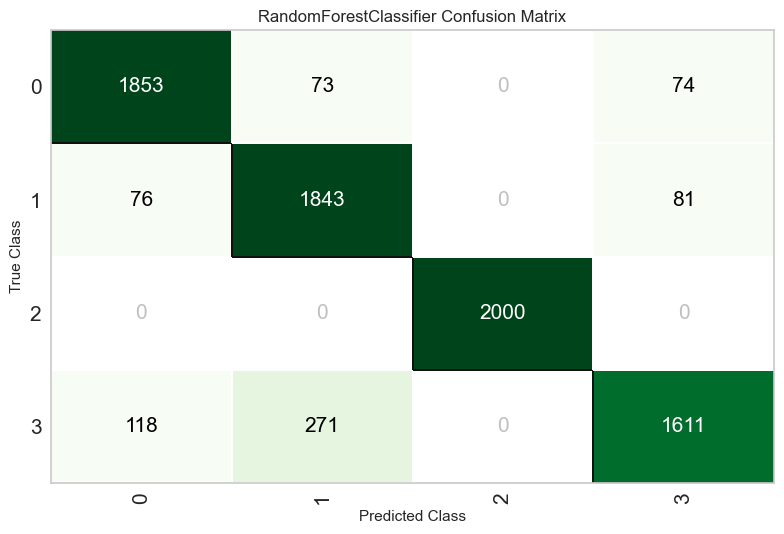

In [16]:
from pycaret.classification import plot_model

s.plot_model(best, plot = 'confusion_matrix')

In [27]:
s.plot_model(best,plot = "validation_curve")

ValueError: Plot Not Available. Please see docstring for list of available Plots.

In [17]:
# save model
s.save_model(best, 'models/best_pipeline_2')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['std_y', 'skewness_y', 'rms_y',
                                              'mean_y', 'kurtosis_y', 'peak_y',
                                              'shape_factor_y',
                                              'impulse_factor_y',
                                              'crest_factor_y',
                                              'clearance_factor_y', 'std_p...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                                         max_depth=None, max_features='sqrt',
                      

In [18]:
from pycaret.classification import load_model

In [19]:
loaded_model = load_model('models/best_pipeline_2')

Transformation Pipeline and Model Successfully Loaded


In [20]:
new_data = [0.32329193086901536,-0.009401830437453615,0.32329193086901536,-1.0516032489249483e-17,1.3941259642292154,0.457350930476456,1.0873584261621894,1.538251779529194,1.4146685605393468,1.651703857805965,28147.848450125948,-0.14988246684151055,28147.848450125948,2.172600943595171e-13,2.3130851368291423,64714.466590624215,1.1646544778091132,2.6776466921563773,2.299091055051302,2.9471072270280216,1432.3264002031437,8000000.0,1423.3119285956218,10750000.0,1335.0155581740373,500000.0,1310.400771426776,5375000.0,1269.7482549286035,9500000.0,1230.4251558013368,2250000.0,1227.0007724029747,4500000.0,1218.9699246620364,2625000.0,1181.0676819835369,6750000.0,1164.3439928597625,6875000.0,298666349.912516,2625000000.0,292353094.7320923,2000000000.0,279459515.7556618,2250000000.0,261187733.3010501,1000000000.0,240438356.5416885,125000000.0,232214282.1914471,875000000.0,228339761.7865269,500000000.0,225497271.95071238,2500000000.0,225360283.7874086,1375000000.0,223539088.25944862,1125000000.0]


In [21]:
scalar = joblib.load('scaler.pkl')
new_data = scalar.transform([new_data])

In [22]:
new_data = pd.DataFrame(new_data, columns=X.columns)

In [23]:
# Assuming 'new_data' is a pandas DataFrame with unseen data
predictions = loaded_model.predict(new_data)

In [24]:
predictions

0    normal
Name: label, dtype: object

In [25]:
# Retrieve the label encoding mapping
label_mapping = s.get_config('idx')
label_mapping

[Index([ 8569, 34910, 23818, 28367, 34535, 13683,  1157, 32317, 24355, 10474,
        ...
        13041, 20235,  8657, 33830, 26118, 19319, 15380, 30628, 18116, 10584],
       dtype='int64', length=32000),
 Index([ 8536, 18072,  3191, 35031, 39963, 37593,  7995, 24426,  9468, 26898,
        ...
         2806, 10703,    33, 21452,  8700, 18796,   882,  7096, 18522, 24515],
       dtype='int64', length=8000)]

In [26]:
conf_df = pd.DataFrame(s._display_container[0])
target_mapping = conf_df[conf_df['Description'] == 'Target mapping']['Value'].values
print(target_mapping)

['air_exposed: 0, normal: 1, tapping: 2, water_exposed: 3']
